In [168]:
import os
import yaml
import errno
import subprocess
import ROOT
import json
import pyarrow as pa
import pyarrow.parquet as pq
from scipy.stats import poisson
import glob
import numpy as np
import pandas as pd 
from scipy.optimize import minimize, curve_fit
import matplotlib.pyplot as plt
import mplhep as hep
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Rectangle
import ROOT
from collections import defaultdict
from itertools import groupby
from itertools import islice
from tqdm import tqdm



production_XS = {
    "GluGluHtoGG": 51.96,
    "GluGluHto2G": 51.96,
    "VBFHtoGG": 4.067,
    "VBFHto2G": 4.067,
    "VHtoGG": 2.3781,
    "VHto2G": 2.3781,
    "ttHtoGG": 0.5638,
    "ttHto2G": 0.5638,
    "bbHtoGG": 0.49,
    "bbHto2G": 0.49,
}

lumiMap = {
    '2016':36.33, 
    '2018':59.83, 
    'combined':137.65, 
    'merged':137.65,
    '2022preEE':8.00,
    '2022postEE':26.70,
    '2022': 34.7,
    '2023preBPix': 17.8,
    '2023postBPix': 9.5,
    '2023': 27.3
}

In [132]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [133]:
def collapse_subcategories(variable_sideband_counts):
    collapsed = defaultdict(float)
    for key, val in variable_sideband_counts.items():
        # Strip suffix like "_cat0"
        main_cat = key.split("_cat")[0]
        collapsed[main_cat] += val
    return dict(collapsed)  

def collapse_category_list(category_list):
    seen = {}
    for k in category_list:
        main_cat = k.split("_cat")[0]
        if main_cat not in seen:
            seen[main_cat] = True
    return list(seen.keys())

import re

def natural_sort_key(s):
    # Convert strings like "RECO_PTH_15p0_30p0" into tokens:
    # ['RECO_PTH_', 15.0, '_', 30.0, '']
    return [float(x.replace('p', '.')) if re.match(r'\d+p\d+', x) else x
            for x in re.split(r'(\d+p\d+)', s)]

In [175]:
# I want to see how the sidebands are extracted
considered_variables = ["PTH", "NJ", "rapidity", "PTJ0", "DPhiJ0J1"]
considered_variables = ["NJ", "PTH", "PTJ0", "DPhiJ0J1", "rapidity"]

considered_variables = sorted(considered_variables, key=natural_sort_key)
# Get all categories

all_cats = {}

for variable in considered_variables:
    
    all_cats[variable] = {}

    # Opening the file and loading the toy
    f = ROOT.TFile.Open(f"/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/{variable}/Replicas/bonly/higgsCombineToy_0.GenerateOnly.mH125.38.123456.root")
    # f = ROOT.TFile.Open(f"/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/intermediateRun3/finalfits/{variable}/Replicas/bonly/higgsCombineToy_0.GenerateOnly.mH125.38.123456.root")
    f.cd("toys")
    t = ROOT.gDirectory.Get("toy_1")

    # Get the variable 'CMS_hgg_mass' from the dataset
    mass = t.get().find("CMS_hgg_mass")
    argset = ROOT.RooArgSet(mass)
    channel = t.get().find("CMS_channel")

    # Extract CMS channel labels and indices
    # This corresponds to the categories in the category dictionary
    CMS_channel_dict = {}
    for i in range(channel.numTypes()):
        channel.setIndex(i)
        CMS_channel_dict[channel.getLabel()] = i
    
    # Group together
    kinematic_cats = collapse_category_list(sorted(list(CMS_channel_dict.keys()), key=natural_sort_key))
    grouped = [list(group)for _, group in groupby(sorted(list(CMS_channel_dict.keys()), key=natural_sort_key), key=lambda x: x.rsplit('_cat', 1)[0])]

    for i, current_kinematic_cat in enumerate(grouped):
        all_cats[variable][kinematic_cats[i]] = current_kinematic_cat

    # all_cats[variable] = grouped

# all_variables = collapse_category_list(all_variables)

print("All categories:", all_cats)


All categories: {'DPhiJ0J1': {'RECO_DPhiJ0J1_0p0_1p0472': ['RECO_DPhiJ0J1_0p0_1p0472_cat0', 'RECO_DPhiJ0J1_0p0_1p0472_cat1', 'RECO_DPhiJ0J1_0p0_1p0472_cat2'], 'RECO_DPhiJ0J1_1p0472_2p0944': ['RECO_DPhiJ0J1_1p0472_2p0944_cat0', 'RECO_DPhiJ0J1_1p0472_2p0944_cat1', 'RECO_DPhiJ0J1_1p0472_2p0944_cat2'], 'RECO_DPhiJ0J1_2p0944_3p1416': ['RECO_DPhiJ0J1_2p0944_3p1416_cat0', 'RECO_DPhiJ0J1_2p0944_3p1416_cat1', 'RECO_DPhiJ0J1_2p0944_3p1416_cat2'], 'RECO_DPhiJ0J1_m1p0472_0p0': ['RECO_DPhiJ0J1_m1p0472_0p0_cat0', 'RECO_DPhiJ0J1_m1p0472_0p0_cat1', 'RECO_DPhiJ0J1_m1p0472_0p0_cat2'], 'RECO_DPhiJ0J1_m2p0944_m1p0472': ['RECO_DPhiJ0J1_m2p0944_m1p0472_cat0', 'RECO_DPhiJ0J1_m2p0944_m1p0472_cat1', 'RECO_DPhiJ0J1_m2p0944_m1p0472_cat2'], 'RECO_DPhiJ0J1_m3p1416_m2p0944': ['RECO_DPhiJ0J1_m3p1416_m2p0944_cat0', 'RECO_DPhiJ0J1_m3p1416_m2p0944_cat1', 'RECO_DPhiJ0J1_m3p1416_m2p0944_cat2']}, 'NJ': {'RECO_NJ_0p0_1p0': ['RECO_NJ_0p0_1p0_cat0', 'RECO_NJ_0p0_1p0_cat1', 'RECO_NJ_0p0_1p0_cat2'], 'RECO_NJ_1p0_2p0': ['RECO_N

In [180]:
all_cats

{'rapidity': {'RECO_rapidity_0p0_0p15': ['RECO_rapidity_0p0_0p15_cat0',
   'RECO_rapidity_0p0_0p15_cat1',
   'RECO_rapidity_0p0_0p15_cat2'],
  'RECO_rapidity_0p15_0p3': ['RECO_rapidity_0p15_0p3_cat0',
   'RECO_rapidity_0p15_0p3_cat1',
   'RECO_rapidity_0p15_0p3_cat2'],
  'RECO_rapidity_0p3_0p6': ['RECO_rapidity_0p3_0p6_cat0',
   'RECO_rapidity_0p3_0p6_cat1',
   'RECO_rapidity_0p3_0p6_cat2'],
  'RECO_rapidity_0p6_0p9': ['RECO_rapidity_0p6_0p9_cat0',
   'RECO_rapidity_0p6_0p9_cat1',
   'RECO_rapidity_0p6_0p9_cat2'],
  'RECO_rapidity_0p9_2p5': ['RECO_rapidity_0p9_2p5_cat0',
   'RECO_rapidity_0p9_2p5_cat1',
   'RECO_rapidity_0p9_2p5_cat2']},
 'PTH': {'RECO_PTH_0p0_15p0': ['RECO_PTH_0p0_15p0_cat0',
   'RECO_PTH_0p0_15p0_cat1',
   'RECO_PTH_0p0_15p0_cat2'],
  'RECO_PTH_15p0_30p0': ['RECO_PTH_15p0_30p0_cat0',
   'RECO_PTH_15p0_30p0_cat1',
   'RECO_PTH_15p0_30p0_cat2'],
  'RECO_PTH_30p0_45p0': ['RECO_PTH_30p0_45p0_cat0',
   'RECO_PTH_30p0_45p0_cat1',
   'RECO_PTH_30p0_45p0_cat2'],
  'RECO_PTH_

In [169]:
# Load main dataset

def chunked(iterable, size):
    it = iter(iterable)
    while True:
        batch = list(islice(it, size))
        if not batch:
            break
        yield batch

data_parquet_files = glob.glob(os.path.join("/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/earlyRun3/data_13_02_26", "*/nominal/*.parquet"))

chunks = []

for file_batch in tqdm(
    chunked(data_parquet_files, size=10),
    total=(len(data_parquet_files) + 9) // 10,
    desc="Loading parquet chunks"
):
    df_chunk = pd.concat(
        (pd.read_parquet(f) for f in file_batch),
        ignore_index=True
    )
    chunks.append(df_chunk)

data_df = pd.concat(chunks, ignore_index=True)

Loading parquet chunks: 100%|█████████████████████████████████████████████████████████| 210/210 [01:55<00:00,  1.82it/s]


In [182]:
# restricted_cats = {"rapidity": all_cats["rapidity"], "PTH": all_cats["PTH"]}
restricted_cats = {"rapidity": all_cats["rapidity"]}

In [190]:
number_of_bootstraps = 1000

all_cats = restricted_cats

if not os.path.exists("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/with_bootstrapping/sideband_counts.parquet"):
    
    sideband_dfs = []
    
    for var in all_cats.keys():
        sideband_counts = {}
        
        # Load the considered variable
        cat_dict_path = os.path.join("/work/niharrin/analyses/MidRun3_Code/postprocessing/configs/cat_dicts", f"2022", "2025_10_31", f"{var}_data.json")
        if not os.path.exists(cat_dict_path):
            print(f"Category dictionary {cat_dict_path} does not exist. Check path in law_replica.py. Exiting...")
            exit(1)
        else:
            with open(cat_dict_path) as pf:
                cat_dict = json.load(pf)
        
        for kinematic_cat in all_cats[var].keys():
            print(f"Processing variable {var}, kinematic category {kinematic_cat}")
            sideband_counts[kinematic_cat] = []
            
            # For each kinematic category, loop over the subcategories and get the sideband counts
            temp_sideband_count = {}
            for cat in all_cats[var][kinematic_cat]:
                temp_sideband_count[cat] = {}
                
                for bootstrap_index in range(0, number_of_bootstraps):
                    temp_sideband_count[cat][f"{bootstrap_index}"] = 0
            
            for cat in all_cats[var][kinematic_cat]:
                # Open up the parquet file
                # df = pd.read_parquet(f"/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/earlyRun3/variables/{var}/merged/Data_2022/allData_{cat}_merged.parquet", columns=["mass", "weight"])
                
                # Apply the cats
                try:
                    query_str = " and ".join(
                        f"{col} {op} {val}" for col, op, val in cat_dict[cat]["cat_filter"]
                    )
                except:
                    # Have a variable using absolute values.
                    query_str = "("
                    for k, set_of_conditions in enumerate(cat_dict[cat]["cat_filter"]):
                        if k > 0:
                            query_str += ") or ("
                        query_str += " and ".join(
                            f"{col} {op} {val}" for col, op, val in set_of_conditions
                        )
                    query_str += ")"
                print(f"Processing category {cat} with query: {query_str}")
                
                start_seed = 123456
                
                for bootstrap_index in range(0, number_of_bootstraps):
                    
                    seed = start_seed + bootstrap_index
                
                    # Now create Poissonian weights
                    rng = np.random.default_rng(seed=seed)
                    weight_poissonian = rng.poisson(1, size=len(data_df))
                    data_df["weight"] = weight_poissonian
                    
                    current_cat_bootstrap = data_df.query(query_str).copy()
                    
                    mass_mask = ((current_cat_bootstrap["mass"] >= 100) & (current_cat_bootstrap["mass"] <= 115)) | ((current_cat_bootstrap["mass"] >= 135) & (current_cat_bootstrap["mass"] <= 180))
                    temp_sideband_count[cat][f"{bootstrap_index}"] += int((current_cat_bootstrap[mass_mask]["weight"]).sum())
                                
            # Now sum up the temp_sideband_count according to the kinematic cat
            for bootstrap_index in range(0, number_of_bootstraps):
                total_for_bootstrap = 0
                for cat in all_cats[var][kinematic_cat]:
                    total_for_bootstrap += temp_sideband_count[cat][f"{bootstrap_index}"]
                sideband_counts[kinematic_cat].append(total_for_bootstrap)
                            
        sideband_dfs.append(pd.DataFrame(sideband_counts))
    
    # sideband_counts = pd.concat([sideband_counts, pd.DataFrame([per_seed_counts])], ignore_index=True)
    sideband_counts = pd.concat(sideband_dfs, axis=1, ignore_index=False)
    
    # sideband_dfs = pd.concat([sideband_df for sideband_df in sideband_dfs], ignore_index=True)
    print(f"{sideband_counts}")

#     sideband_counts.to_parquet("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/with_bootstrapping/sideband_counts.parquet")

# else:
#     sideband_counts = pd.read_parquet("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/with_bootstrapping/sideband_counts.parquet")
            



Processing variable rapidity, kinematic category RECO_rapidity_0p0_0p15
Processing category RECO_rapidity_0p0_0p15_cat0 with query: (rapidity >= 0.0 and rapidity < 0.15 and sigma_m_over_m_smeared_decorr < 0.0105 and lead_mvaID > 0.25 and sublead_mvaID > 0.25) or (rapidity <= -0.0 and rapidity > -0.15 and sigma_m_over_m_smeared_decorr < 0.0105 and lead_mvaID > 0.25 and sublead_mvaID > 0.25)
Processing category RECO_rapidity_0p0_0p15_cat1 with query: (rapidity >= 0.0 and rapidity < 0.15 and sigma_m_over_m_smeared_decorr > 0.0105 and sigma_m_over_m_smeared_decorr < 0.013 and lead_mvaID > 0.25 and sublead_mvaID > 0.25) or (rapidity <= -0.0 and rapidity > -0.15 and sigma_m_over_m_smeared_decorr > 0.0105 and sigma_m_over_m_smeared_decorr < 0.013 and lead_mvaID > 0.25 and sublead_mvaID > 0.25)
Processing category RECO_rapidity_0p0_0p15_cat2 with query: (rapidity >= 0.0 and rapidity < 0.15 and sigma_m_over_m_smeared_decorr > 0.013 and sigma_m_over_m_smeared_decorr < 0.0315 and lead_mvaID > 0.2

In [191]:
# sideband_counts = pd.read_parquet("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/sideband_corr_matrix/sideband_counts_5000.parquet")

print(sideband_counts.columns)
desired_order = ['RECO_DPhiJ0J1_2p0944_3p1416', 'RECO_DPhiJ0J1_1p0472_2p0944', 'RECO_DPhiJ0J1_0p0_1p0472', 'RECO_DPhiJ0J1_m1p0472_0p0', 'RECO_DPhiJ0J1_m2p0944_m1p0472', 'RECO_DPhiJ0J1_m3p1416_m2p0944', 'RECO_NJ_3p0_100p0', 'RECO_NJ_2p0_3p0', 'RECO_NJ_1p0_2p0', 'RECO_NJ_0p0_1p0', 'RECO_PTH_0p0_15p0', 'RECO_PTH_15p0_30p0', 'RECO_PTH_30p0_45p0', 'RECO_PTH_45p0_80p0', 'RECO_PTH_80p0_120p0', 'RECO_PTH_120p0_200p0', 'RECO_PTH_200p0_350p0', 'RECO_PTH_350p0_10000p0', 'RECO_PTJ0_30p0_75p0', 'RECO_PTJ0_75p0_120p0', 'RECO_PTJ0_120p0_200p0', 'RECO_PTJ0_200p0_10000p0', 'RECO_rapidity_0p0_0p15', 'RECO_rapidity_0p15_0p3', 'RECO_rapidity_0p3_0p6', 'RECO_rapidity_0p6_0p9', 'RECO_rapidity_0p9_2p5']

desired_order = ['RECO_NJ_0p0_1p0', 'RECO_NJ_1p0_2p0', 'RECO_NJ_2p0_3p0', 'RECO_NJ_3p0_100p0', 'RECO_PTH_0p0_15p0', 'RECO_PTH_15p0_30p0', 'RECO_PTH_30p0_45p0', 'RECO_PTH_45p0_80p0', 'RECO_PTH_80p0_120p0', 'RECO_PTH_120p0_200p0', 'RECO_PTH_200p0_350p0', 'RECO_PTH_350p0_10000p0']

# desired_order = ['RECO_PTJ0_30p0_75p0', 'RECO_PTJ0_75p0_120p0', 'RECO_PTJ0_120p0_200p0', 'RECO_PTJ0_200p0_10000p0', 'RECO_NJ_3p0_100p0', 'RECO_NJ_2p0_3p0', 'RECO_NJ_1p0_2p0', 'RECO_NJ_0p0_1p0', 'RECO_PTH_0p0_15p0', 'RECO_PTH_15p0_30p0', 'RECO_PTH_30p0_45p0', 'RECO_PTH_45p0_80p0', 'RECO_PTH_80p0_120p0', 'RECO_PTH_120p0_200p0', 'RECO_PTH_200p0_350p0', 'RECO_PTH_350p0_10000p0']

sideband_counts = sideband_counts[desired_order]

Index(['RECO_rapidity_0p0_0p15', 'RECO_rapidity_0p15_0p3',
       'RECO_rapidity_0p3_0p6', 'RECO_rapidity_0p6_0p9',
       'RECO_rapidity_0p9_2p5'],
      dtype='object')


KeyError: "None of [Index(['RECO_NJ_0p0_1p0', 'RECO_NJ_1p0_2p0', 'RECO_NJ_2p0_3p0',\n       'RECO_NJ_3p0_100p0', 'RECO_PTH_0p0_15p0', 'RECO_PTH_15p0_30p0',\n       'RECO_PTH_30p0_45p0', 'RECO_PTH_45p0_80p0', 'RECO_PTH_80p0_120p0',\n       'RECO_PTH_120p0_200p0', 'RECO_PTH_200p0_350p0',\n       'RECO_PTH_350p0_10000p0'],\n      dtype='object')] are in the [columns]"

In [192]:
# print(sideband_counts[["RECO_PTH_0p0_15p0", "RECO_PTH_15p0_30p0", "RECO_PTH_30p0_45p0", "RECO_PTH_45p0_80p0", "RECO_PTH_80p0_120p0", "RECO_PTH_120p0_200p0", "RECO_PTH_200p0_350p0", "RECO_PTH_350p0_10000p0"]])
# print(sideband_counts[["RECO_NJ_0p0_1p0", "RECO_NJ_1p0_2p0", "RECO_NJ_2p0_3p0", "RECO_NJ_3p0_100p0"]])
print(sideband_counts["RECO_rapidity_0p0_0p15"].corr(sideband_counts["RECO_rapidity_0p3_0p6"]))

0.043815289367630315


In [193]:
print(sideband_counts["RECO_rapidity_0p0_0p15"].std())
print(sideband_counts["RECO_rapidity_0p0_0p15"].mean())
print(sideband_counts["RECO_rapidity_0p0_0p15"].median())

162.44554635486483
26459.595
26464.0


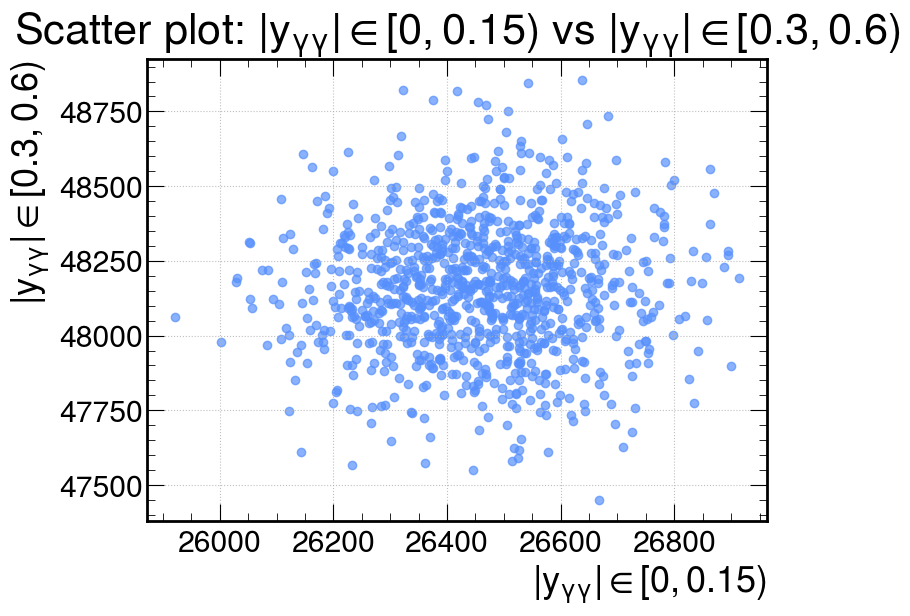

In [194]:
# Example: scatter plot between two variables
plt.figure(figsize=(8, 6))
plt.scatter(sideband_counts["RECO_rapidity_0p0_0p15"], sideband_counts["RECO_rapidity_0p3_0p6"], alpha=0.7)
# plt.scatter(sideband_counts["RECO_PTH_0p0_15p0"], sideband_counts["RECO_NJ_0p0_1p0"], alpha=0.7)
plt.xlabel(translation["RECO_rapidity_0p0_0p15"])
plt.ylabel(translation["RECO_rapidity_0p3_0p6"])
plt.title(f"Scatter plot: {translation['RECO_rapidity_0p0_0p15']} vs {translation['RECO_rapidity_0p3_0p6']}")
plt.grid(True)
plt.show()

In [195]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

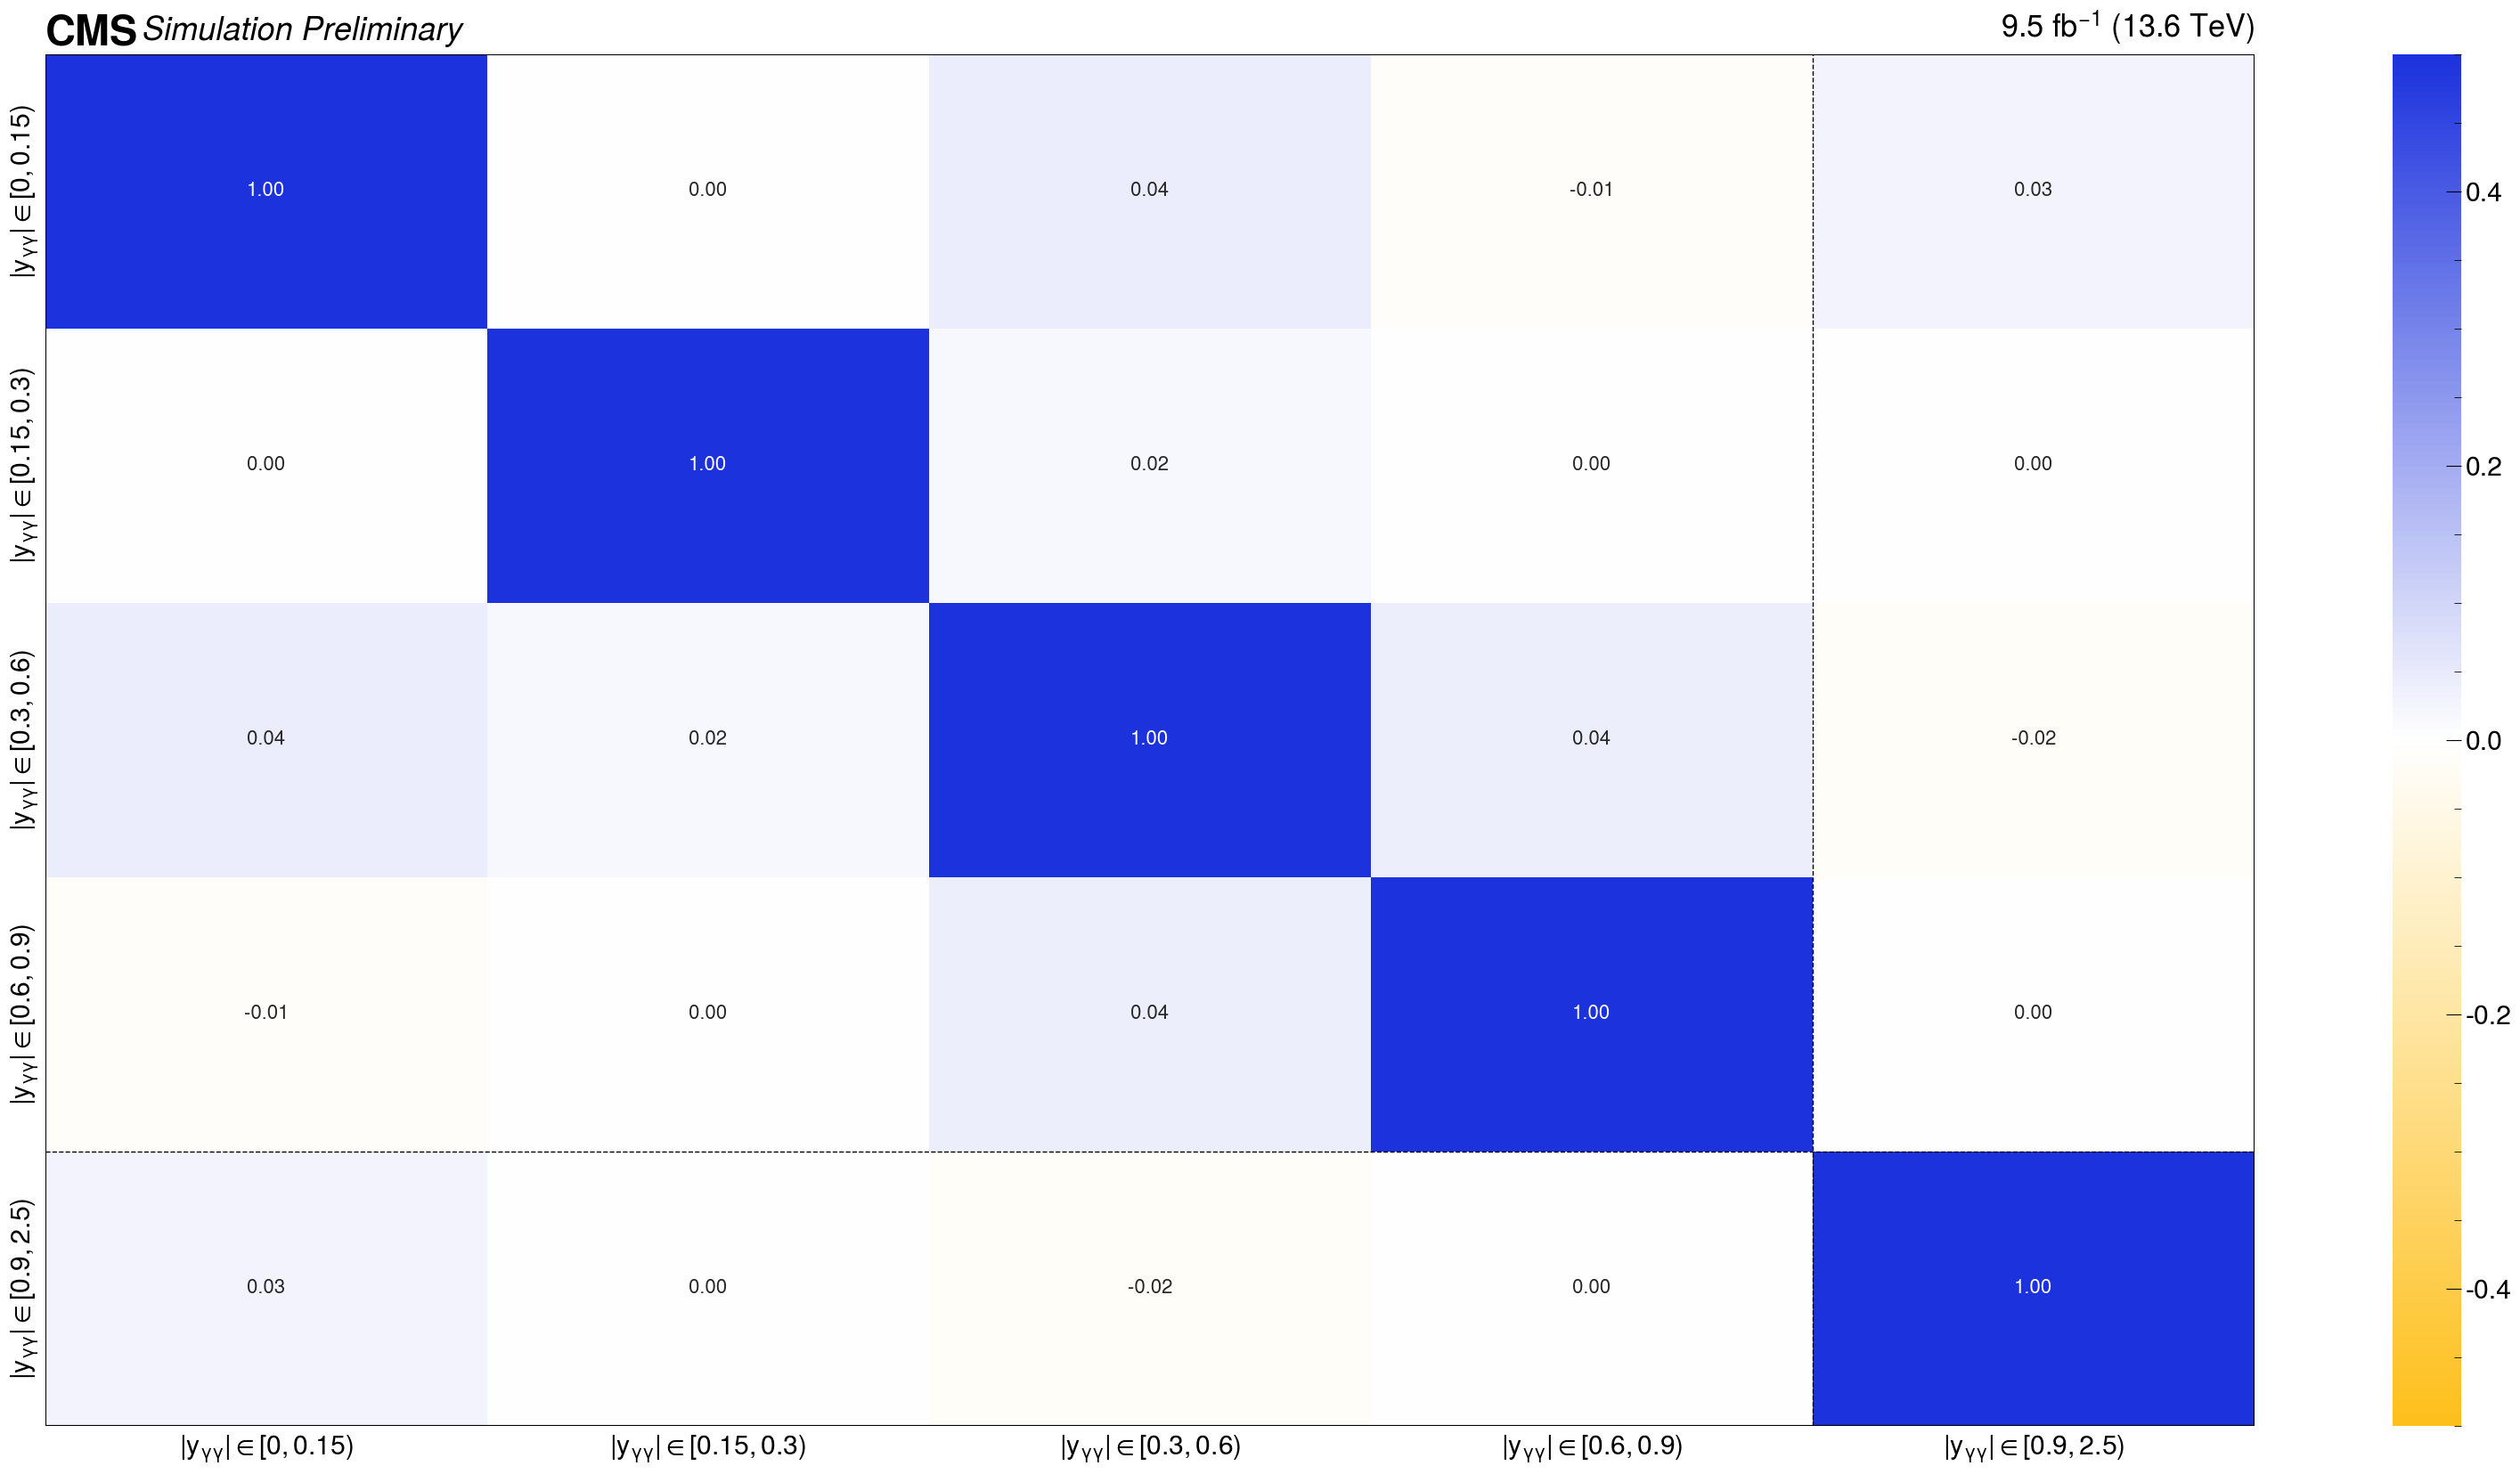

In [196]:
modified_corr_matrix = (sideband_counts.corr()).copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(40, 20)) # 28, 14
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6) # 27.3
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [4, 15, 18, 23]  # Example indices between variable blocks # 6, 10, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/with_bootstrapping", "correlation_matrix.pdf"), bbox_inches='tight')
plt.savefig(os.path.join("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/with_bootstrapping", "correlation_matrix.png"), bbox_inches='tight')

# plt.close()

In [39]:
# I want to plot the Mass distribution
first_pt_bin_list = ["/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/PTH/merged/Data_2023/DataD_2023_RECO_PTH_0p0_15p0_cat0_merged.parquet", "/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/PTH/merged/Data_2023/DataD_2023_RECO_PTH_0p0_15p0_cat1_merged.parquet", "/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/PTH/merged/Data_2023/DataD_2023_RECO_PTH_0p0_15p0_cat2_merged.parquet"]

first_pt_bin_list = ["/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/PTH/merged/Data_2023/DataD_2023_RECO_PTH_0p0_15p0_cat0_merged.parquet"]


first_nj_bin_list = ["/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/NJ/merged/Data_2023/DataD_2023_RECO_NJ_0p0_1p0_cat0_merged.parquet", "/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/NJ/merged/Data_2023/DataD_2023_RECO_NJ_0p0_1p0_cat1_merged.parquet", "/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_18_bootstrapping/variables/NJ/merged/Data_2023/DataD_2023_RECO_NJ_0p0_1p0_cat2_merged.parquet"]

df_pt = pd.read_parquet(first_pt_bin_list, columns=["mass"] + [f"weight_bootstrap_{i}" for i in range(0, number_of_bootstraps)]+ ["weight_central"])
df_nj = pd.read_parquet(first_nj_bin_list, columns=["mass"] + [f"weight_bootstrap_{i}" for i in range(0, number_of_bootstraps)]+ ["weight_central"])

In [43]:
# Mass mask
mass_mask_pt = ((df_pt["mass"] >= 100) & (df_pt["mass"] <= 115)) | ((df_pt["mass"] >= 135) & (df_pt["mass"] <= 180))
mass_mask_nj = ((df_nj["mass"] >= 100) & (df_nj["mass"] <= 115)) | ((df_nj["mass"] >= 135) & (df_nj["mass"] <= 180))

# df_pt[mass_mask_pt]
df_nj[mass_mask_nj]

,mass,weight_bootstrap_0,weight_bootstrap_1,weight_bootstrap_2,weight_bootstrap_3,weight_bootstrap_4,weight_bootstrap_5,weight_bootstrap_6,weight_bootstrap_7,weight_bootstrap_8,...,weight_bootstrap_991,weight_bootstrap_992,weight_bootstrap_993,weight_bootstrap_994,weight_bootstrap_995,weight_bootstrap_996,weight_bootstrap_997,weight_bootstrap_998,weight_bootstrap_999,weight_central
1,158.603750,1,2,1,1,2,0,2,0,0,...,2,2,1,1,2,0,0,0,0,1
3,114.053618,0,2,2,1,1,1,1,2,4,...,4,3,2,0,2,1,2,0,1,1
5,106.704394,2,0,0,1,0,3,0,0,1,...,1,1,1,0,1,0,0,1,1,1
6,142.874063,1,2,1,0,0,3,2,1,0,...,3,4,2,2,1,0,1,2,0,1
9,110.838249,2,0,0,0,1,1,1,0,2,...,2,0,1,0,0,2,1,1,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68765,177.363111,2,0,2,0,0,1,0,1,0,...,2,1,2,2,2,0,0,0,1,1
68766,152.856393,1,0,1,1,0,1,0,4,2,...,2,0,1,1,2,1,0,0,2,1
68767,176.889967,1,0,2,0,0,1,0,1,2,...,2,2,0,0,1,1,1,1,1,1
68769,103.232608,0,2,0,1,0,2,0,1,1,...,0,2,1,2,1,0,1,1,2,1


In [42]:
import ROOT
# Opening the file and loading the toy
# f = ROOT.TFile.Open(f"/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/{variable}/Replicas/bonly/higgsCombineToy_{index}.GenerateOnly.mH125.38.{seed}.root")
f = ROOT.TFile.Open(f"/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix/PTH/Replicas/bonly/higgsCombineToy_0.GenerateOnly.mH125.38.123456.root")

f.cd("toys")
t = ROOT.gDirectory.Get("toy_1")

# Get the variable 'CMS_hgg_mass' from the dataset
mass = t.get().find("CMS_hgg_mass")
argset = ROOT.RooArgSet(mass)
channel = t.get().find("CMS_channel")

# Extract CMS channel labels and indices
# This corresponds to the categories in the category dictionary
CMS_channel_dict = {}
for i in range(channel.numTypes()):
    channel.setIndex(i)
    CMS_channel_dict[channel.getLabel()] = i

print("Available CMS_channel categories:", CMS_channel_dict)

# Pre-initialize counters (avoids dict growth inside loop)
varibale_sideband_counts = {cat: 0.0 
                for cat in CMS_channel_dict}

# Loop once over dataset
nEntries = t.numEntries()
# print("Number of entries:", nEntries)
for i in range(nEntries):
    t.get(i)  # fills 'obs' with entry values
    mval = mass.getVal()
    clabel = channel.getLabel()
    w = t.weight()
    
    # print(f"Entry {i}: mass={mval}, category={clabel}, weight={w}")

    if 100 <= mval <= 115:
        # varibale_sideband_counts[clabel]["lowSB"] += w
        varibale_sideband_counts[clabel] += w
        # pass
    elif 135 <= mval <= 180:
        # varibale_sideband_counts[clabel]["highSB"] += w
        varibale_sideband_counts[clabel] += w
        # pass
    
    # varibale_sideband_counts[clabel] += w
        
# varibale_sideband_counts = collapse_subcategories(varibale_sideband_counts)

print(varibale_sideband_counts)

Available CMS_channel categories: {'RECO_PTH_0p0_15p0_cat0': 0, 'RECO_PTH_0p0_15p0_cat1': 1, 'RECO_PTH_0p0_15p0_cat2': 2, 'RECO_PTH_120p0_200p0_cat0': 3, 'RECO_PTH_120p0_200p0_cat1': 4, 'RECO_PTH_120p0_200p0_cat2': 5, 'RECO_PTH_15p0_30p0_cat0': 6, 'RECO_PTH_15p0_30p0_cat1': 7, 'RECO_PTH_15p0_30p0_cat2': 8, 'RECO_PTH_200p0_350p0_cat0': 9, 'RECO_PTH_200p0_350p0_cat1': 10, 'RECO_PTH_200p0_350p0_cat2': 11, 'RECO_PTH_30p0_45p0_cat0': 12, 'RECO_PTH_30p0_45p0_cat1': 13, 'RECO_PTH_30p0_45p0_cat2': 14, 'RECO_PTH_350p0_10000p0_cat0': 15, 'RECO_PTH_350p0_10000p0_cat1': 16, 'RECO_PTH_350p0_10000p0_cat2': 17, 'RECO_PTH_45p0_80p0_cat0': 18, 'RECO_PTH_45p0_80p0_cat1': 19, 'RECO_PTH_45p0_80p0_cat2': 20, 'RECO_PTH_80p0_120p0_cat0': 21, 'RECO_PTH_80p0_120p0_cat1': 22, 'RECO_PTH_80p0_120p0_cat2': 23}
{'RECO_PTH_0p0_15p0_cat0': 2334.0, 'RECO_PTH_0p0_15p0_cat1': 5648.0, 'RECO_PTH_0p0_15p0_cat2': 16768.0, 'RECO_PTH_120p0_200p0_cat0': 221.0, 'RECO_PTH_120p0_200p0_cat1': 447.0, 'RECO_PTH_120p0_200p0_cat2': 11

In [1]:
import ROOT
# Opening the file and loading the toy
# f = ROOT.TFile.Open(f"/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/{variable}/Replicas/bonly/higgsCombineToy_{index}.GenerateOnly.mH125.38.{seed}.root")
f = ROOT.TFile.Open(f"/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/PTH_blindedBkgFit/Background/outdir_Run3FidXSAnalysis_PTH/CMS-HGG_multipdf_RECO_PTH_0p0_15p0_cat0.root")

# t = f.Get("multipdf")
f.ls()


TFile**		/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/PTH_blindedBkgFit/Background/outdir_Run3FidXSAnalysis_PTH/CMS-HGG_multipdf_RECO_PTH_0p0_15p0_cat0.root	
 TFile*		/t3home/niharrin/devel/pnfs/ntuples/midRun3/samples/2025_09_06_powheg/finalfits/PTH_blindedBkgFit/Background/outdir_Run3FidXSAnalysis_PTH/CMS-HGG_multipdf_RECO_PTH_0p0_15p0_cat0.root	
  KEY: RooWorkspace	multipdf;1	
  KEY: TProcessID	ProcessID0;1	25859456-a5be-11f0-bc0c-ae7b21c0beef


Warning in <TClass::Init>: no dictionary for class RooMultiPdf is available
Warning in <TClass::Init>: no dictionary for class RooBernsteinFast<4> is available
Warning in <TClass::Init>: no dictionary for class RooPower is available


In [ ]:
t = f.Get("multipdf")

: 

: 

: 

In [ ]:


# Get the variable 'CMS_hgg_mass' from the dataset
mass = t.get().find("CMS_hgg_mass")
argset = ROOT.RooArgSet(mass)
channel = t.get().find("CMS_channel")

# Extract CMS channel labels and indices
# This corresponds to the categories in the category dictionary
CMS_channel_dict = {}
for i in range(channel.numTypes()):
    channel.setIndex(i)
    CMS_channel_dict[channel.getLabel()] = i

print("Available CMS_channel categories:", CMS_channel_dict)

# Pre-initialize counters (avoids dict growth inside loop)
varibale_sideband_counts = {cat: 0.0 
                for cat in CMS_channel_dict}

# Loop once over dataset
nEntries = t.numEntries()
# print("Number of entries:", nEntries)
for i in range(nEntries):
    t.get(i)  # fills 'obs' with entry values
    mval = mass.getVal()
    clabel = channel.getLabel()
    w = t.weight()
    
    # print(f"Entry {i}: mass={mval}, category={clabel}, weight={w}")

    # if 100 <= mval <= 115:
    #     # varibale_sideband_counts[clabel]["lowSB"] += w
    #     varibale_sideband_counts[clabel] += w
    #     # pass
    # elif 135 <= mval <= 180:
    #     # varibale_sideband_counts[clabel]["highSB"] += w
    #     varibale_sideband_counts[clabel] += w
    #     # pass
    
    varibale_sideband_counts[clabel] += w
        
# varibale_sideband_counts = collapse_subcategories(varibale_sideband_counts)

print(varibale_sideband_counts)